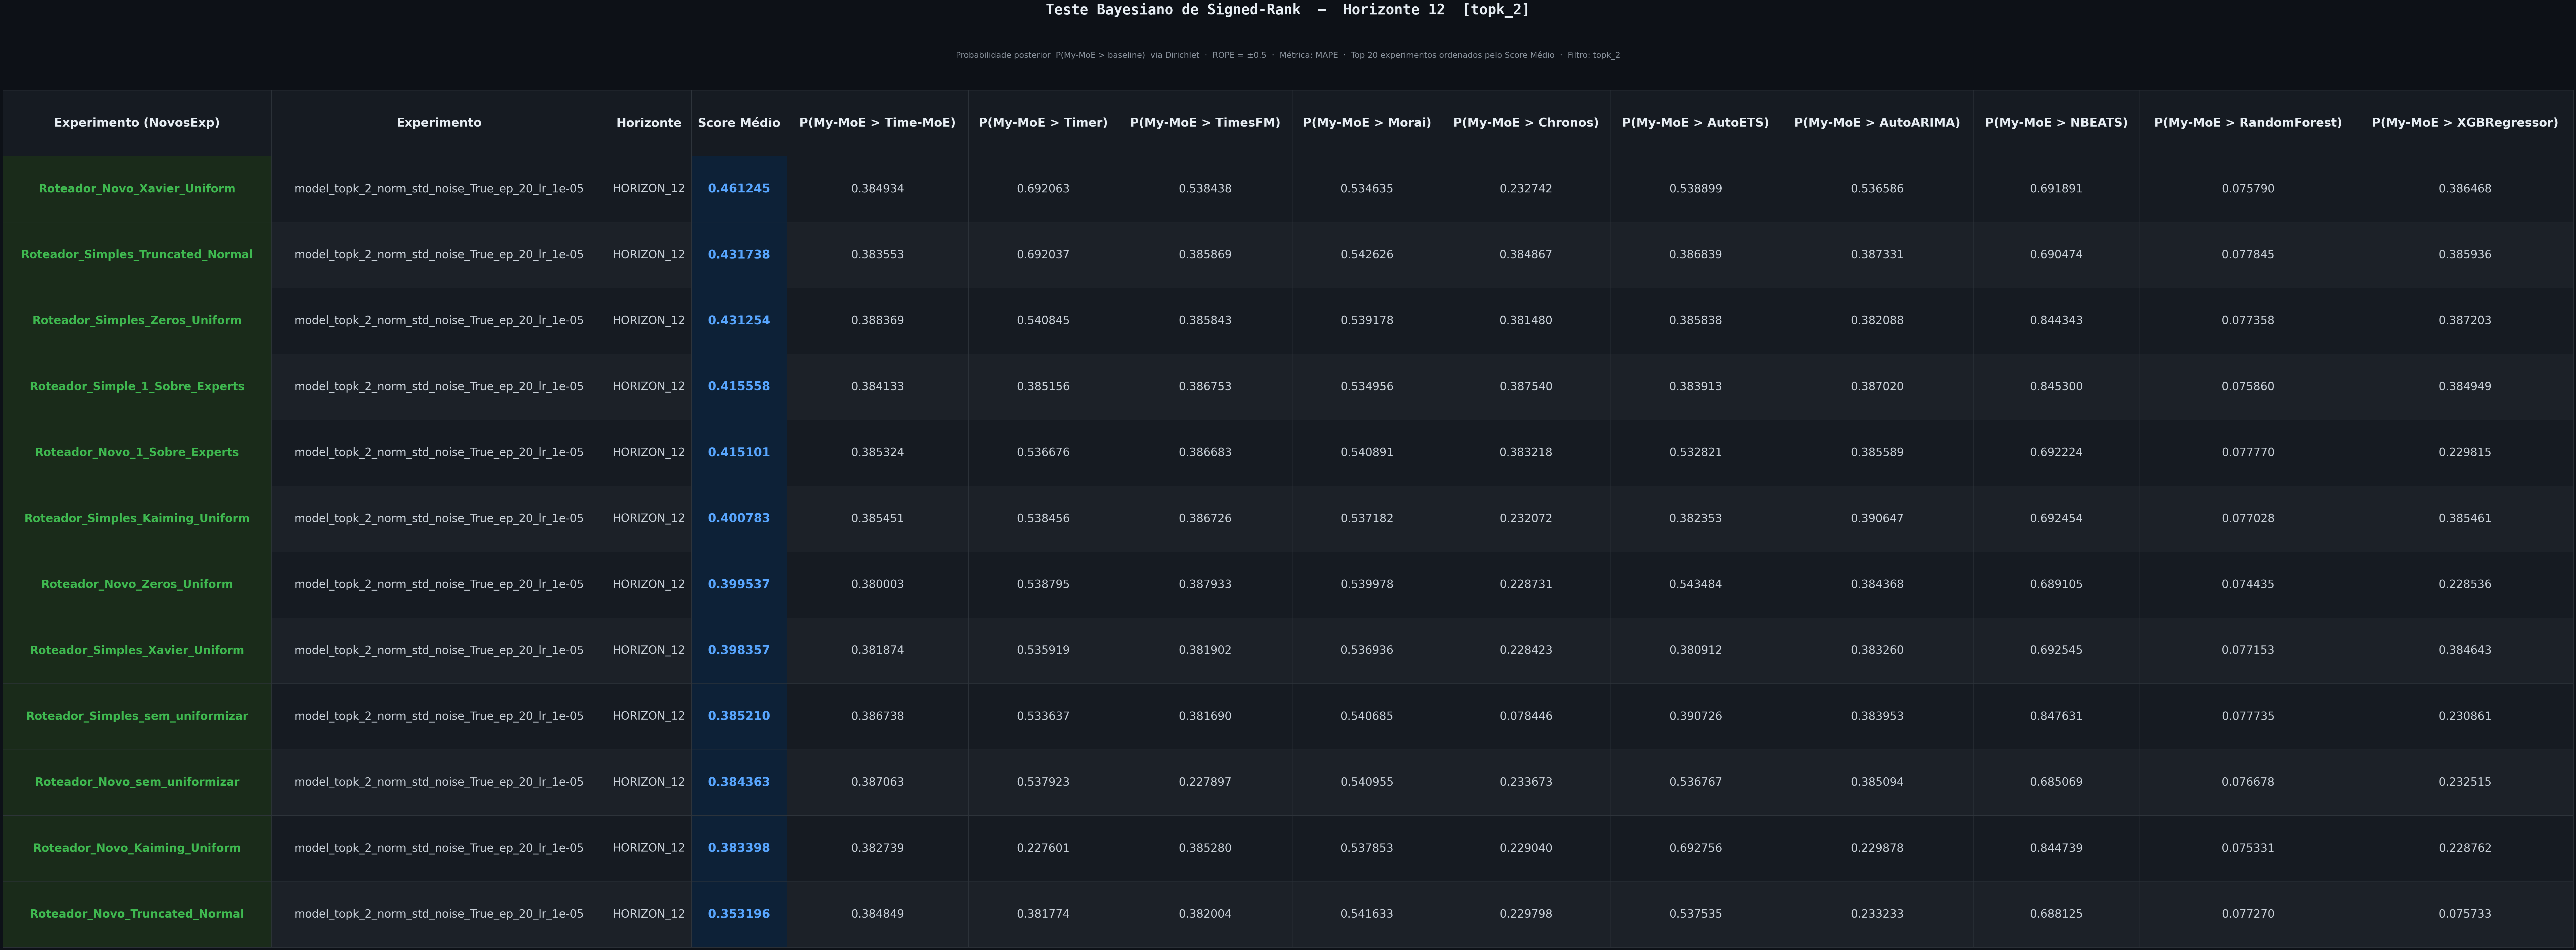

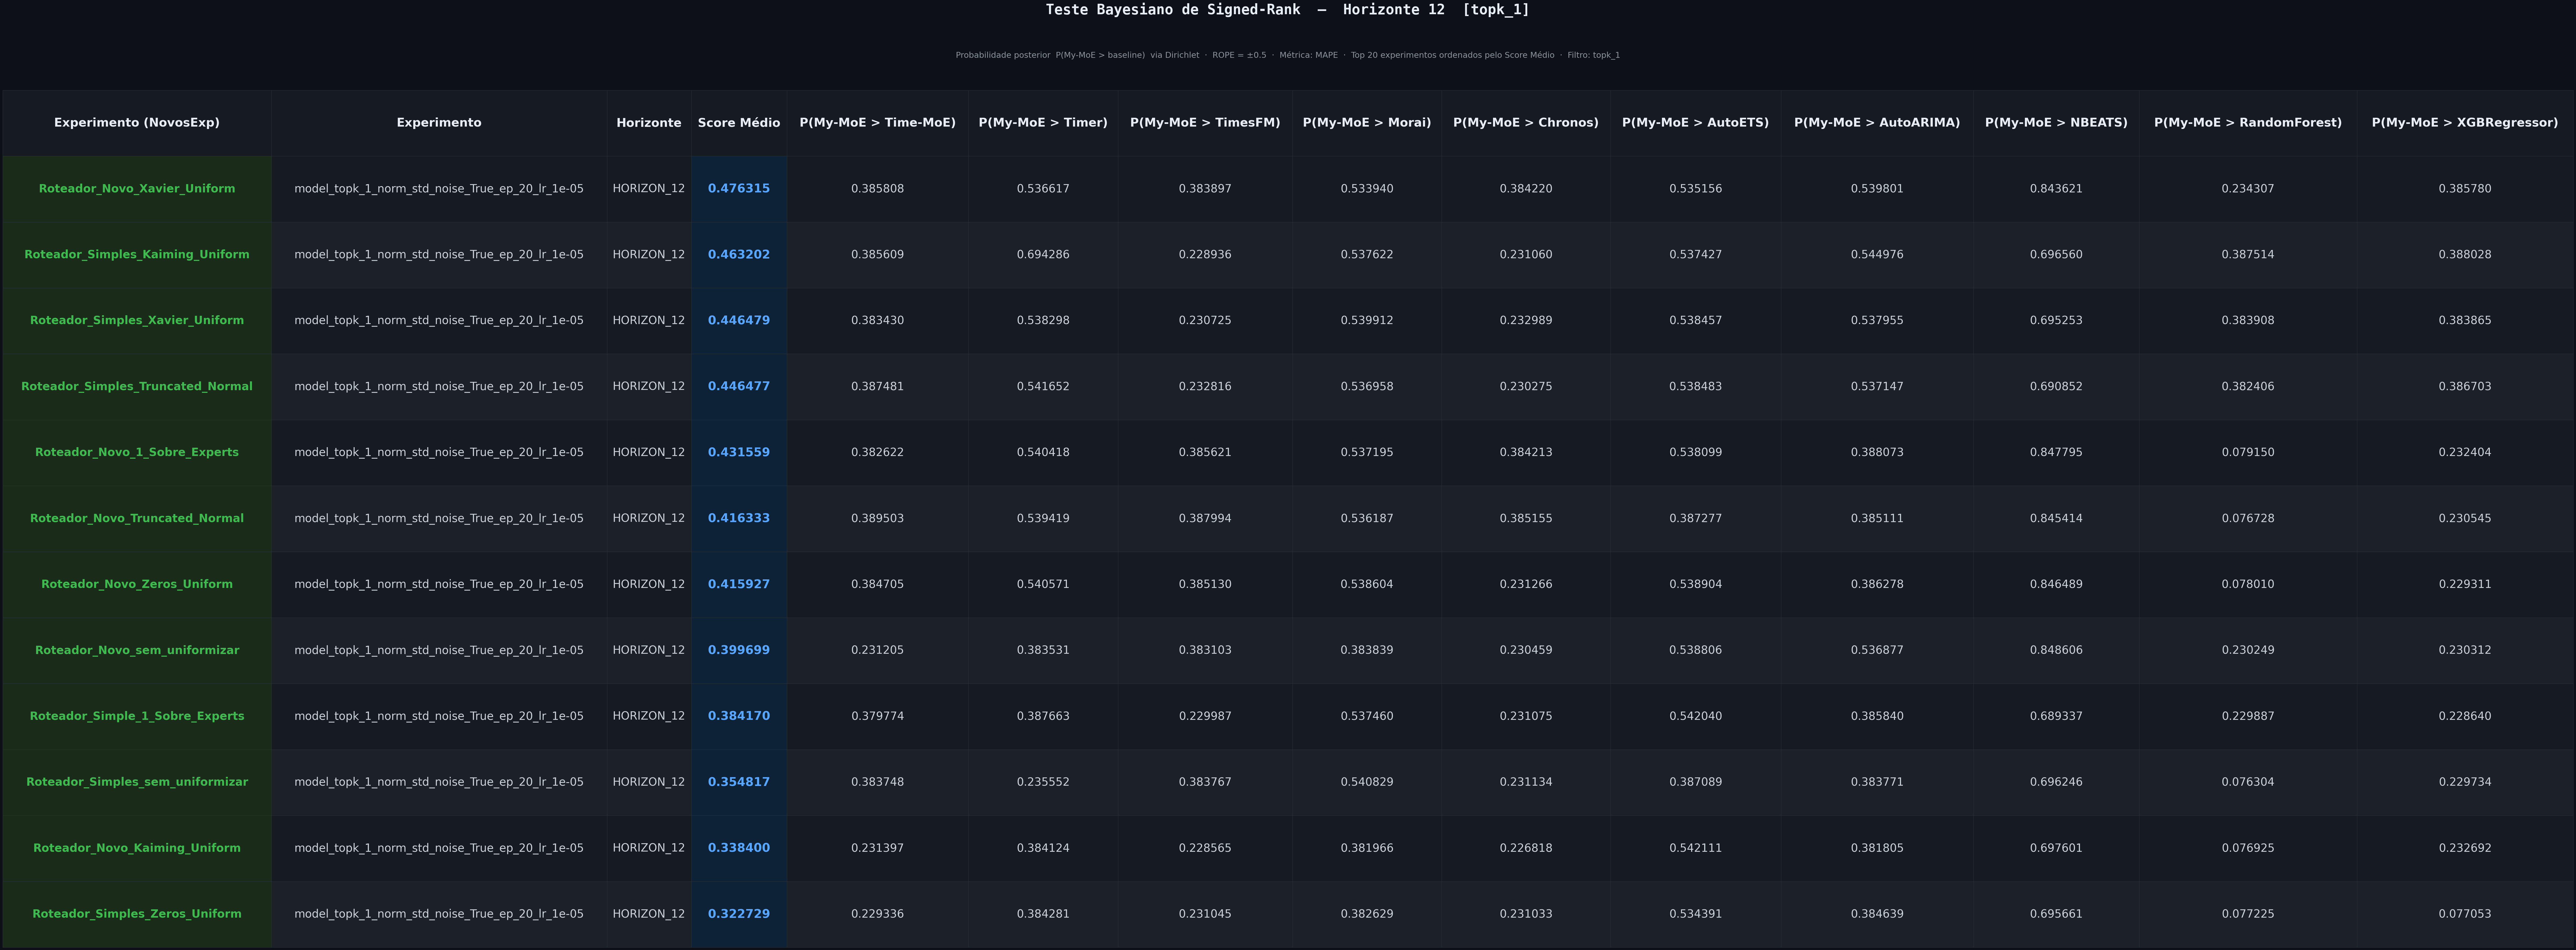

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# ========================
# CONFIG
# ========================
NOVOS_EXP_ROOT = "NovosExp"
RESULTS_SUBDIR = "results_by_state_year"
MY_MOE_NAME    = "My-MoE"
ROPE           = 0.5
TOP_K          = 20

target_products = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

# ========================
# BAYESIAN FUNCTIONS
# ========================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    diffs   = np.array(differences)
    n_left  = np.sum(diffs < -rope)
    n_rope  = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)
    alpha   = np.array([n_left + s, n_rope + s, n_right + s])
    posterior = np.random.dirichlet(alpha, size=5000)
    return posterior.mean(axis=0)


def prob_A_better_than_B(df, A, B, rope=0.5, metric="MAPE"):
    dfA = df[df["Modelo"] == A][metric].values
    dfB = df[df["Modelo"] == B][metric].values
    if len(dfA) != len(dfB):
        raise ValueError(f"{A} e {B} com tamanhos diferentes.")
    diffs = dfB - dfA
    _, _, theta_A_better = bayesian_signed_rank(diffs, rope)
    return theta_A_better


# ========================
# COLETA DE RESULTADOS
# ========================
rows_by_horizon = defaultdict(list)

for exp_name in sorted(os.listdir(NOVOS_EXP_ROOT)):
    exp_root = os.path.join(NOVOS_EXP_ROOT, exp_name)
    if not os.path.isdir(exp_root):
        continue

    base_results_path = os.path.join(exp_root, RESULTS_SUBDIR)
    if not os.path.isdir(base_results_path):
        print(f"[AVISO] Sem '{RESULTS_SUBDIR}' em: {exp_root}")
        continue

    for experiment_name in sorted(os.listdir(base_results_path)):
        experiment_path = os.path.join(base_results_path, experiment_name)
        if not os.path.isdir(experiment_path):
            continue

        for horizon_folder in sorted(os.listdir(experiment_path)):
            horizon_path = os.path.join(experiment_path, horizon_folder)
            if not os.path.isdir(horizon_path) or not horizon_folder.startswith("horizon_"):
                continue

            horizon  = horizon_folder.upper()
            all_data = []

            for file in os.listdir(horizon_path):
                if not file.endswith(".csv"):
                    continue

                df    = pd.read_csv(os.path.join(horizon_path, file))
                parts = file.replace(".csv", "").split("_")
                year  = int(parts[-1])
                state = parts[-2].upper()

                df_long = df.melt(id_vars=["Modelo"], var_name="Produto", value_name="MAPE")
                df_long["Year"]  = year
                df_long["State"] = state
                all_data.append(df_long)

            if not all_data:
                continue

            df_all = pd.concat(all_data, ignore_index=True)
            df_all = (df_all
                      .replace([np.inf, -np.inf], np.nan)
                      .dropna(subset=["MAPE"]))
            df_all = df_all[df_all["Produto"].isin(target_products)]

            modelos       = df_all["Modelo"].unique()
            my_moe_models = [m for m in modelos if MY_MOE_NAME in m]
            if not my_moe_models:
                continue
            my_moe = my_moe_models[0]

            row = {
                "Experimento_Global": exp_name,
                "Experimento":        experiment_name,
                "Horizonte":          horizon
            }

            probs = []
            for other_model in modelos:
                if other_model == my_moe:
                    continue
                p = prob_A_better_than_B(df_all, my_moe, other_model, rope=ROPE)
                row[f"Prob_MyMoE_vs_{other_model}"] = p
                probs.append(p)

            row["Score_Medio_MyMoE"] = np.mean(probs) if probs else np.nan
            rows_by_horizon[horizon].append(row)


# ========================
# DATAFRAMES FINAIS
# ========================
dfs_by_horizon = {
    h: pd.DataFrame(rows)
       .sort_values("Score_Medio_MyMoE", ascending=False)
       .reset_index(drop=True)
    for h, rows in rows_by_horizon.items()
}


# ========================
# VISUAL TABLE (matplotlib)
# ========================
def plot_table(df, horizon, top_k=TOP_K, subtitle_extra=""):
    prob_cols = [c for c in df.columns if c.startswith("Prob_MyMoE_vs_")]
    show_cols = ["Experimento_Global", "Experimento", "Horizonte", "Score_Medio_MyMoE"] + prob_cols
    show_cols = [c for c in show_cols if c in df.columns]
    df_plot   = df[show_cols].head(top_k).copy()

    # formata floats
    for c in df_plot.select_dtypes(include="float").columns:
        df_plot[c] = df_plot[c].map(lambda x: f"{x:.6f}" if pd.notna(x) else "—")

    # renomeia colunas
    rename = {
        "Score_Medio_MyMoE":  "Score Médio",
        "Experimento_Global": "Experimento (NovosExp)",
    }
    for c in prob_cols:
        rename[c] = "P(My-MoE > " + c.replace("Prob_MyMoE_vs_", "") + ")"
    df_plot.rename(columns=rename, inplace=True)

    n_rows, n_cols = df_plot.shape

    col_w = 7.0
    row_h = 2.2
    fig_w = max(56, n_cols * col_w)
    fig_h = max(22, n_rows * row_h + 10.0)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.axis("off")

    # paleta dark
    HDR_BG   = "#161b22"
    HDR_FG   = "#e6edf3"
    ROW_EVEN = "#1c2128"
    ROW_ODD  = "#161b22"
    SCORE_BG = "#0d2137"
    SCORE_FG = "#58a6ff"
    EXP_BG   = "#1a2b1a"
    EXP_FG   = "#3fb950"
    EDGE_COL = "#30363d"

    tbl = ax.table(
        cellText  = df_plot.values,
        colLabels = df_plot.columns,
        cellLoc   = "center",
        loc       = "center",
        bbox      = [0.0, 0.0, 1.0, 1.0],
    )
    tbl.auto_set_font_size(False)
    tbl.auto_set_column_width(col=list(range(n_cols)))

    col_names = list(df_plot.columns)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor(EDGE_COL)
        cell.set_linewidth(0.7)
        col_name = col_names[c] if c < len(col_names) else ""

        if r == 0:
            cell.set_facecolor(HDR_BG)
            cell.set_text_props(color=HDR_FG, fontweight="bold", fontsize=32)
            cell.set_height(cell.get_height() * 4.5)
        else:
            cell.set_facecolor(ROW_EVEN if r % 2 == 0 else ROW_ODD)
            cell.set_text_props(color="#c9d1d9", fontsize=30)

            if col_name == "Score Médio":
                cell.set_facecolor(SCORE_BG)
                cell.set_text_props(color=SCORE_FG, fontweight="bold", fontsize=32)

            if col_name == "Experimento (NovosExp)":
                cell.set_facecolor(EXP_BG)
                cell.set_text_props(color=EXP_FG, fontweight="bold", fontsize=30)

            cell.set_height(cell.get_height() * 4.5)

    # título principal
    horizon_num = horizon.replace("HORIZON_", "")
    title = f"Teste Bayesiano de Signed-Rank  —  Horizonte {horizon_num}"
    if subtitle_extra:
        title += f"  [{subtitle_extra}]"
    fig.text(
        0.5, 0.98,
        title,
        ha="center", va="top",
        fontsize=38, fontweight="bold", color="#e6edf3",
        fontfamily="monospace"
    )
    fig.text(
        0.5, 0.93,
        (
            f"Probabilidade posterior  P(My-MoE > baseline)  via Dirichlet  ·  "
            f"ROPE = ±{ROPE}  ·  Métrica: MAPE  ·  "
            f"Top {top_k} experimentos ordenados pelo Score Médio"
            + (f"  ·  Filtro: {subtitle_extra}" if subtitle_extra else "")
        ),
        ha="center", va="top",
        fontsize=22, color="#8b949e",
    )

    plt.subplots_adjust(top=0.89, bottom=0.01, left=0.01, right=0.99)
    plt.show()


def filter_by_topk(df, topk_tag):
    """Filtra linhas onde Experimento_Global ou Experimento contém topk_tag."""
    mask = (
        df["Experimento_Global"].str.contains(topk_tag, case=False, na=False) |
        df["Experimento"].str.contains(topk_tag, case=False, na=False)
    )
    return df[mask].reset_index(drop=True)


# ========================
# GERAÇÃO DOS PLOTS
# ========================
for h, df_h in sorted(dfs_by_horizon.items()):

    # Plot 1 — todos os experimentos (original)
    plot_table(df_h, horizon=h, top_k=TOP_K)

    # Plot 2 — apenas experimentos com topk_2
    df_topk2 = filter_by_topk(df_h, "topk_2")
    if not df_topk2.empty:
        plot_table(df_topk2, horizon=h, top_k=TOP_K, subtitle_extra="topk_2")
    else:
        print(f"[AVISO] Nenhum experimento com 'topk_2' no horizonte {h}")

    # Plot 3 — apenas experimentos com topk_1
    df_topk1 = filter_by_topk(df_h, "topk_1")
    if not df_topk1.empty:
        plot_table(df_topk1, horizon=h, top_k=TOP_K, subtitle_extra="topk_1")
    else:
        print(f"[AVISO] Nenhum experimento com 'topk_1' no horizonte {h}")

In [8]:
import os
import csv
from collections import defaultdict

# Caminho base onde estão os experimentos
BASE_PATH = "NovosExp"  # Altere para o caminho correto, ex: "/caminho/para/NovosExp"

def find_and_print_experiments(base_path):
    # Estrutura: base_path / Roteador_* / output_dir / topk_* / experts_weights_summary.csv
    
    for roteador in sorted(os.listdir(base_path)):
        roteador_path = os.path.join(base_path, roteador)
        if not os.path.isdir(roteador_path):
            continue

        output_dir = os.path.join(roteador_path, "output_dir")
        if not os.path.isdir(output_dir):
            continue

        experiments = sorted(os.listdir(output_dir))
        if not experiments:
            continue

        print(f"\n{'='*60}")
        print(f"📁 {roteador}")
        print(f"{'='*60}")

        for experiment in experiments:
            experiment_path = os.path.join(output_dir, experiment)
            if not os.path.isdir(experiment_path):
                continue

            # Procura o csv dentro de subpastas (ex: excluding_sp) ou direto
            csv_files = []
            for root, dirs, files in os.walk(experiment_path):
                for f in files:
                    if f == "experts_weights_summary.csv":
                        csv_files.append(os.path.join(root, f))

            if not csv_files:
                continue

            print(f"\n  🔬 {experiment}")

            for csv_path in csv_files:
                # Pega o nome da subpasta (ex: excluding_sp)
                subfolder = os.path.basename(os.path.dirname(csv_path))
                if subfolder != experiment:
                    print(f"    [{subfolder}]")

                # Lê o CSV e agrupa por Learner
                learner_data = defaultdict(int)
                try:
                    with open(csv_path, newline='', encoding='utf-8') as f:
                        reader = csv.DictReader(f)
                        for row in reader:
                            learner = row.get("Learner", "Unknown")
                            selections = int(row.get("selections", 0))
                            learner_data[learner] += selections
                except Exception as e:
                    print(f"    ⚠️  Erro ao ler {csv_path}: {e}")
                    continue

                for learner, total_selections in sorted(learner_data.items()):
                    print(f"      {learner}: {total_selections}")

find_and_print_experiments(BASE_PATH)


📁 Roteador_Novo_1_Sobre_Experts

  🔬 topk_1_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 903
      Moirai: 639
      Time-MoE: 733
      Timer: 753
      TimesFM: 716

  🔬 topk_2_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 1568
      Moirai: 1514
      Time-MoE: 1432
      Timer: 1482
      TimesFM: 1492

📁 Roteador_Novo_Kaiming_Uniform

  🔬 topk_1_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 904
      Moirai: 506
      Time-MoE: 891
      Timer: 1021
      TimesFM: 630

  🔬 topk_2_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 1676
      Moirai: 1236
      Time-MoE: 1881
      Timer: 2101
      TimesFM: 1426

📁 Roteador_Novo_Truncated_Normal

  🔬 topk_1_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 884
      Moirai: 813
      Time-MoE: 559
      Timer: 810
      TimesFM: 678

  🔬 topk_2_norm_std_noise_True_ep_20_lr_1e-05
      Chronos: 1056
      Moirai: 1217
      Time-MoE: 762
      Timer: 1060
      TimesFM: 897

📁 Roteador_Novo_Xavier_Uniform

  🔬 topk_1_no

In [ ]:
import pandas as pd
from pathlib import Path

# ========================
# CONFIGURAÇÃO
# ========================
BASE_OUTPUT_PATH = "NovosExp/Roteador_Novo_1_Sobre_Experts/output_dir"
TOP_K = 3  # Define quantos TOP experimentos você quer analisar

# ========================
# FUNÇÕES AUXILIARES
# ========================

def extract_year_from_experiment(experiment_name):
    """
    Extrai o ano do nome do experimento
    """
    parts = experiment_name.split('_')
    for part in parts:
        if len(part) == 4 and part.isdigit():
            year = int(part)
            if 2000 <= year <= 2030:
                return year
    return None


def normalize_experiment_name(name):
    """
    Normaliza o nome do experimento para facilitar matching
    Remove 'model_' do início e padroniza
    """
    # Remove 'model_' do início
    if name.startswith('model_'):
        name = name[6:]
    return name


def find_experiment_directory(experiment_name, base_path):
    """
    Encontra o diretório do experimento baseado no nome
    """
    base_path = Path(base_path)
    
    # Normaliza o nome do experimento
    normalized_exp = normalize_experiment_name(experiment_name)
    
    # Tenta encontrar o diretório
    for exp_dir in base_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        dir_name = exp_dir.name
        normalized_dir = normalize_experiment_name(dir_name)
        
        # Match exato (com ou sem 'model_')
        if (dir_name == experiment_name or 
            normalized_dir == normalized_exp or
            dir_name == normalized_exp or
            normalized_dir == experiment_name):
            return exp_dir
        
        # Match parcial - verifica se o experimento está contido no nome do diretório
        if normalized_exp in normalized_dir or experiment_name in dir_name:
            # Valida parâmetros chave para evitar falsos positivos
            key_params = ['topk', 'norm', 'noise', 'ep', 'lr']
            
            exp_params = {}
            exp_parts = experiment_name.split('_')
            for i, part in enumerate(exp_parts):
                if part in key_params and i + 1 < len(exp_parts):
                    exp_params[part] = exp_parts[i + 1]
            
            dir_params = {}
            dir_parts = dir_name.split('_')
            for i, part in enumerate(dir_parts):
                if part in key_params and i + 1 < len(dir_parts):
                    dir_params[part] = dir_parts[i + 1]
            
            # Verifica se os parâmetros correspondem
            if all(dir_params.get(k) == v for k, v in exp_params.items()):
                return exp_dir
    
    return None


def get_experiment_data_from_directory(experiment_name, base_path):
    """
    Busca os dados do experimento diretamente na pasta dele
    """
    exp_dir = find_experiment_directory(experiment_name, base_path)
    
    if exp_dir is None:
        return None, None
    
    # Lê os arquivos
    epochs_file = exp_dir / "epochs_per_experiment.csv"
    experts_file = exp_dir / "experts_weights_summary.csv"
    
    df_epochs = None
    df_experts = None
    
    if epochs_file.exists():
        df_epochs = pd.read_csv(epochs_file)
    
    if experts_file.exists():
        df_experts = pd.read_csv(experts_file)
    
    return df_epochs, df_experts


def get_experiment_details_by_base_name(experiment_name, base_path, target_horizon):
    """
    Retorna detalhes do experimento para um horizonte específico
    """
    df_epochs, df_experts = get_experiment_data_from_directory(experiment_name, base_path)
    
    if df_epochs is None:
        return None
    
    # Normaliza o nome do horizonte (HORIZON_12 -> horizon_12)
    target_horizon_lower = target_horizon.lower()
    
    # Filtra apenas o horizonte desejado
    horizon_data = df_epochs[df_epochs['horizon'] == target_horizon_lower]
    
    if horizon_data.empty:
        return None
    
    # Encontra maior e menor número de épocas
    max_epochs_row = horizon_data.loc[horizon_data['num_epochs'].idxmax()]
    min_epochs_row = horizon_data.loc[horizon_data['num_epochs'].idxmin()]
    
    max_epochs = int(max_epochs_row['num_epochs'])
    min_epochs = int(min_epochs_row['num_epochs'])
    
    max_year = int(max_epochs_row['year']) if 'year' in max_epochs_row else extract_year_from_experiment(max_epochs_row['experiment'])
    min_year = int(min_epochs_row['year']) if 'year' in min_epochs_row else extract_year_from_experiment(min_epochs_row['experiment'])
    
    # Pega a min_loss diretamente da linha (que é a loss da última época)
    max_last_loss = float(max_epochs_row['min_loss']) if 'min_loss' in max_epochs_row else None
    min_last_loss = float(min_epochs_row['min_loss']) if 'min_loss' in min_epochs_row else None
    
    # Média de épocas
    media_epochs = horizon_data['num_epochs'].mean()
    
    details = {
        'max_epochs': max_epochs,
        'max_last_loss': max_last_loss,
        'max_year': max_year,
        'min_epochs': min_epochs,
        'min_last_loss': min_last_loss,
        'min_year': min_year,
        'media_epochs': media_epochs
    }
    
    return details


def get_learner_stats_for_base_name(experiment_name, base_path, target_horizon):
    """
    Retorna estatísticas agregadas de learners para um horizonte específico
    """
    _, df_experts = get_experiment_data_from_directory(experiment_name, base_path)
    
    if df_experts is None or df_experts.empty:
        return pd.DataFrame()
    
    # Normaliza o nome do horizonte
    target_horizon_lower = target_horizon.lower()
    
    # Filtra apenas o horizonte desejado
    df_experts_filtered = df_experts[df_experts['horizon'] == target_horizon_lower]
    
    if df_experts_filtered.empty:
        return pd.DataFrame()
    
    # Agrupa por learner (soma seleções, média de pesos)
    learner_stats = df_experts_filtered.groupby('Learner').agg({
        'selections': 'sum',
        'avg_weight': 'mean'
    }).reset_index()
    
    learner_stats.columns = ['Learner', 'Total Seleções', 'Peso Médio']
    learner_stats['Total Seleções'] = learner_stats['Total Seleções'].astype(int)
    learner_stats = learner_stats.sort_values('Total Seleções', ascending=False)
    
    return learner_stats


# ========================
# PROCESSAR dfs_by_horizon
# ========================

# Verifica se dfs_by_horizon existe
try:
    dfs_by_horizon
except NameError:
    print("\n❌ ERRO: dfs_by_horizon não encontrado!")
    print("Execute primeiro o código que gera dfs_by_horizon")
    exit(1)

base_path = Path(BASE_OUTPUT_PATH)

# Para cada horizonte
for h, df_h in dfs_by_horizon.items():
    print("\n" + "=" * 100)
    print(f"DETALHAMENTO — {h}")
    print("=" * 100)
    
    # TOP EXPERIMENTOS QUE MAIS GANHAM
    print("\n" + "─" * 100)
    print(f"MELHOR DESEMPENHO — {h}")
    print("─" * 100)
    
    top_ganham = df_h.head(TOP_K)
    
    for idx, (_, row) in enumerate(top_ganham.iterrows(), 1):
        experiment_name = row['Experimento']
        
        print(f"\n{'·' * 100}")
        print(f"TOP {idx}: {experiment_name}")
        print(f"{'·' * 100}")
        
        # Busca detalhes do experimento APENAS para o horizonte atual
        info = get_experiment_details_by_base_name(experiment_name, base_path, h)
        
        if info is None:
            print(f"⚠️ Dados não encontrados para {experiment_name} no horizonte {h}")
            continue
        
        max_loss_str = f"{info['max_last_loss']:.2f}" if info['max_last_loss'] is not None else "N/A"
        min_loss_str = f"{info['min_last_loss']:.2f}" if info['min_last_loss'] is not None else "N/A"
        
        print(f"  Maior número de Épocas: {info['max_epochs']:<3} | Última Loss para essa época: {max_loss_str:>6} | Ano = {info['max_year']}")
        print(f"  Menor número de Épocas: {info['min_epochs']:<3} | Última Loss para essa época: {min_loss_str:>6} | Ano = {info['min_year']}")
        print(f"  Média de épocas de todos os anos = {info['media_epochs']:.1f}")
        
        # Estatísticas de learners APENAS para o horizonte atual
        learner_stats = get_learner_stats_for_base_name(experiment_name, base_path, h)
        
        if not learner_stats.empty:
            print(f"\nEstatísticas de Learners:")
            for _, learner_row in learner_stats.iterrows():
                print(f"  {learner_row['Learner']:15s} | Seleções: {learner_row['Total Seleções']:8d} | Peso médio: {learner_row['Peso Médio']:.4f}")
    
    
    # TOP EXPERIMENTOS QUE MAIS PERDEM
    print("\n" + "─" * 100)
    print(f"PIOR DESEMPENHO — {h}")
    print("─" * 100)
    
    top_perdem = df_h.tail(TOP_K)
    
    for idx, (_, row) in enumerate(top_perdem.iterrows(), 1):
        experiment_name = row['Experimento']
        
        print(f"\n{'·' * 100}")
        print(f"PIOR {idx}: {experiment_name}")
        print(f"{'·' * 100}")
        
        # Busca detalhes do experimento APENAS para o horizonte atual
        info = get_experiment_details_by_base_name(experiment_name, base_path, h)
        
        if info is None:
            print(f"⚠️ Dados não encontrados para {experiment_name} no horizonte {h}")
            continue
        
        max_loss_str = f"{info['max_last_loss']:.2f}" if info['max_last_loss'] is not None else "N/A"
        min_loss_str = f"{info['min_last_loss']:.2f}" if info['min_last_loss'] is not None else "N/A"
        
        print(f"  Maior número de Épocas: {info['max_epochs']:<3} | Última Loss para essa época: {max_loss_str:>6} | Ano = {info['max_year']}")
        print(f"  Menor número de Épocas: {info['min_epochs']:<3} | Última Loss para essa época: {min_loss_str:>6} | Ano = {info['min_year']}")
        print(f"  Média de épocas de todos os anos = {info['media_epochs']:.1f}")
        
        # Estatísticas de learners APENAS para o horizonte atual
        learner_stats = get_learner_stats_for_base_name(experiment_name, base_path, h)
        
        if not learner_stats.empty:
            print(f"\nEstatísticas de Learners:")
            for _, learner_row in learner_stats.iterrows():
                print(f"  {learner_row['Learner']:15s} | Seleções: {learner_row['Total Seleções']:8d} | Peso médio: {learner_row['Peso Médio']:.4f}")


print("\n" + "=" * 100)
print("✅ Análise completa!")
print("=" * 100)


DETALHAMENTO — HORIZON_12

────────────────────────────────────────────────────────────────────────────────────────────────────
MELHOR DESEMPENHO — HORIZON_12
────────────────────────────────────────────────────────────────────────────────────────────────────

····································································································
TOP 1: model_topk_2_norm_std_noise_True_ep_30_lr_1e-05
····································································································
  Maior número de Épocas: 30  | Última Loss para essa época:   0.27 | Ano = 2021
  Menor número de Épocas: 11  | Última Loss para essa época:   0.14 | Ano = 2023
  Média de épocas de todos os anos = 20.6

Estatísticas de Learners:
  TimesFM         | Seleções:     8943 | Peso médio: 0.5114
  Moirai          | Seleções:     8763 | Peso médio: 0.4883
  Chronos         | Seleções:     8639 | Peso médio: 0.5039
  Timer           | Seleções:     8514 | Peso médio: 0.4914
  Time-MoE